### Preprocessing

In [1]:
import json
import re
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from collections import Counter
from nltk import bigrams
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [2]:
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/cyprienfourcroy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/cyprienfourcroy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
nltk.download("wordnet")    
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/cyprienfourcroy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/cyprienfourcroy/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [9]:
with open("datasets/putin_complete.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

print("HEAD (raw):")
print(df.head(2))
print("\nNumber of rows:", len(df))
print("Columns:", df.columns.tolist())

text_cols = ["transcript_unfiltered", "transcript_filtered"]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df[df["date"].notna()].reset_index(drop=True)

putin_mask = df["transcript_unfiltered"].str.contains(r"\bPutin\b\s*:", regex=True, na=False)
df = df[putin_mask].reset_index(drop=True)

df["transcript_unfiltered"] = df["transcript_unfiltered"].str.replace(
    r"^.*\bPutin\b\s*:\s*", "", regex=True
)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df["text_raw"] = df["transcript_filtered"].where(
    df["transcript_filtered"].str.len() > 0,
    df["transcript_unfiltered"]
)

df["sentences"] = df["text_raw"].apply(
    lambda x: re.split(r"(?<=[.!?])\s+", x.strip()) if x.strip() else []
)

df["sentence_count"] = df["sentences"].apply(len)

def ensure_wordlist(row):
    wl = row.get("wordlist", None)
    if not isinstance(wl, list) or len(wl) == 0:
        return word_tokenize(row["text_raw"])
    return wl

df["tokens_full"] = df.apply(ensure_wordlist, axis=1)

def clean_tokens(tokens):
    return [t.lower() for t in tokens if t.strip() != ""]

df["tokens_clean"] = df["tokens_full"].apply(clean_tokens)

def keep_alpha_tokens(tokens):
    return [t for t in tokens if re.fullmatch(r"[a-z]+", t)]

df["tokens_lexical"] = df["tokens_clean"].apply(keep_alpha_tokens)

stop_words = set(stopwords.words("english"))

df["tokens_nostop"] = df["tokens_lexical"].apply(
    lambda x: [t for t in x if t not in stop_words]
)

lemmatizer = WordNetLemmatizer()

df["tokens_lemma"] = df["tokens_nostop"].apply(
    lambda toks: [lemmatizer.lemmatize(t) for t in toks]
)

df["token_count"] = df["tokens_lexical"].apply(len)
df["unique_tokens"] = df["tokens_lexical"].apply(lambda x: len(set(x)))

df["lexical_diversity"] = df.apply(
    lambda r: r["unique_tokens"] / r["token_count"] if r["token_count"] > 0 else 0,
    axis=1
)

df["avg_sentence_length"] = df.apply(
    lambda r: r["token_count"] / r["sentence_count"] if r["sentence_count"] > 0 else 0,
    axis=1
)

def rhetorical_features(text):
    return {
        "exclamation_count": text.count("!"),
        "question_count": text.count("?"),
        "ellipsis_count": text.count("...")
    }

rhet_feats = df["text_raw"].apply(rhetorical_features)
rhet_df = pd.DataFrame(list(rhet_feats))
df = pd.concat([df, rhet_df], axis=1)

HEAD (raw):
                  date persons  \
0  1999-12-31T00:01:00      []   
1  1999-12-31T00:02:00      []   

                               transcript_unfiltered  kremlin_id  \
0  Vladimir Putin: Dear friends, On New Year’s Ev...     22280.0   
1  Vladimir Putin: Good afternoon, distinguished ...     22326.0   

                 place                                              title  \
0  The Kremlin, Moscow  New Year Address by Acting President Vladimir ...   
1  The Kremlin, Moscow  Address at an expanded meeting of the Russian ...   

  teaser tags                                transcript_filtered  \
0          []  Dear friends, On New Year’s Eve, my family and...   
1          []  Good afternoon, distinguished colleagues. This...   

                                            wordlist  
0  [dear, friend, ,, on, New, Year, ’s, Eve, ,, m...  
1  [good, afternoon, ,, distinguished, colleague,...  

Number of rows: 9838
Columns: ['date', 'persons', 'transcript_unfiltered', 'k

In [9]:
df.to_json(
    "datasets/putin_complete_cleaned.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print("\nSaved cleaned dataset: putin_complete_cleaned.json")


Saved cleaned dataset: putin_complete_cleaned.json


In [5]:
with open("datasets/putin_complete_cleaned.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

### Comparaison

### 1. How does the narrative toward Poland differ from that toward Germany? (Sentiment analysis, RoBERTa)
 

In [7]:
mask_pl = df["transcript_filtered"].str.contains(r"\bPoland\b", case=False, na=False)
mask_de = df["transcript_filtered"].str.contains(r"\bGermany\b", case=False, na=False)

df_pl = df[mask_pl]
df_de = df[mask_de]


In [8]:
df_pl.shape

(144, 27)

In [9]:
df_de.shape

(473, 27)

We are going to use sentiment_roberta_large_english which has a legacy format from HuggingFace

Run the following commands to download the model 

In [ ]:
# # Model weights (large ~1.3–1.4GB)
# curl -L --fail --retry 10 --retry-delay 2 -C - \
#   -o pytorch_model.bin \
#   "https://huggingface.co/siebert/sentiment-roberta-large-english/resolve/main/pytorch_model.bin"

# # Model config
# curl -L --fail --retry 10 --retry-delay 2 \
#   -o config.json \
#   "https://huggingface.co/siebert/sentiment-roberta-large-english/resolve/main/config.json"

# # Tokenizer files (RoBERTa BPE)
# curl -L --fail --retry 10 --retry-delay 2 \
#   -o vocab.json \
#   "https://huggingface.co/siebert/sentiment-roberta-large-english/resolve/main/vocab.json"

# curl -L --fail --retry 10 --retry-delay 2 \
#   -o merges.txt \
#   "https://huggingface.co/siebert/sentiment-roberta-large-english/resolve/main/merges.txt"

# # Tokenizer metadata
# curl -L --fail --retry 10 --retry-delay 2 \
#   -o tokenizer_config.json \
#   "https://huggingface.co/siebert/sentiment-roberta-large-english/resolve/main/tokenizer_config.json"

# curl -L --fail --retry 10 --retry-delay 2 \
#   -o special_tokens_map.json \
#   "https://huggingface.co/siebert/sentiment-roberta-large-english/resolve/main/special_tokens_map.json"



In [10]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_dir = "./sentiment_roberta_large"

tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

print("Loaded labels:", model.config.id2label)


Loaded labels: {0: 'NEGATIVE', 1: 'POSITIVE'}


In [11]:
import torch

text = "Germany is acting irresponsibly, while Poland remains pragmatic."

enc = tokenizer(text, return_tensors="pt", truncation=True)
with torch.no_grad():
    logits = model(**enc).logits
probs = torch.softmax(logits, dim=-1)[0].tolist()

print("probs:", probs)
print("pred:", model.config.id2label[int(torch.argmax(logits))])


probs: [0.9968913197517395, 0.00310869375243783]
pred: NEGATIVE


In [12]:


df_sent = df.explode("sentences").rename(columns={"sentences": "sentence"})
df_sent = df_sent[df_sent["sentence"].str.strip() != ""].reset_index(drop=True)

pl_sent = df_sent[df_sent["sentence"].str.contains(r"\bPoland\b", case=False, na=False)].copy()
de_sent = df_sent[df_sent["sentence"].str.contains(r"\bGermany\b", case=False, na=False)].copy()

print("Poland sentences:", len(pl_sent))
print("Germany sentences:", len(de_sent))


Poland sentences: 364
Germany sentences: 1486


In [13]:
tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
model.eval()


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=Tru

In [14]:
import torch
import numpy as np

def batched_sentiment(texts, tokenizer, model, batch_size=16, max_length=256):
    all_pos_probs = []
    all_labels = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        )

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)

        # model.config.id2label = {0: 'NEGATIVE', 1: 'POSITIVE'}
        pos_index = [k for k,v in model.config.id2label.items() if v == "POSITIVE"][0]

        pos_probs = probs[:, pos_index].cpu().numpy()
        labels = probs.argmax(dim=-1).cpu().numpy()

        all_pos_probs.extend(pos_probs.tolist())
        all_labels.extend(labels.tolist())

    return np.array(all_pos_probs), np.array(all_labels)


In [16]:
pl_texts = pl_sent["sentence"].tolist()
de_texts = de_sent["sentence"].tolist()

pl_pos_probs, pl_labels = batched_sentiment(pl_texts, tokenizer, model, batch_size=16)
de_pos_probs, de_labels = batched_sentiment(de_texts, tokenizer, model, batch_size=16)

pl_sent["pos_prob"] = pl_pos_probs
pl_sent["label"] = pl_labels

de_sent["pos_prob"] = de_pos_probs
de_sent["label"] = de_labels


In [17]:
def sentiment_proportions(df_local):
    total = len(df_local)
    pos = (df_local["label"] == 1).sum()
    neg = (df_local["label"] == 0).sum()
    return {
        "positive": pos / total if total > 0 else 0,
        "negative": neg / total if total > 0 else 0,
        "count": total
    }

pl_props = sentiment_proportions(pl_sent)
de_props = sentiment_proportions(de_sent)

print("Poland sentiment distribution:", pl_props)
print("Germany sentiment distribution:", de_props)


Poland sentiment distribution: {'positive': np.float64(0.6318681318681318), 'negative': np.float64(0.36813186813186816), 'count': 364}
Germany sentiment distribution: {'positive': np.float64(0.8055181695827726), 'negative': np.float64(0.19448183041722747), 'count': 1486}


In [18]:
import matplotlib.pyplot as plt
import numpy as np


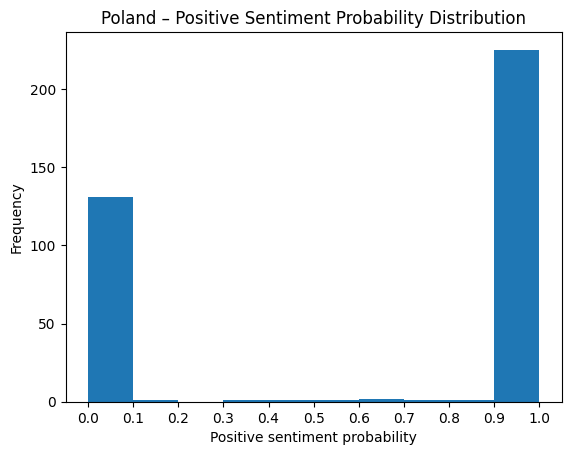

In [20]:
bins = np.arange(0, 1.1, 0.1)

plt.figure()
plt.hist(pl_sent["pos_prob"], bins=bins)
plt.title("Poland – Positive Sentiment Probability Distribution")
plt.xlabel("Positive sentiment probability")
plt.ylabel("Frequency")
plt.xticks(bins)
plt.show()



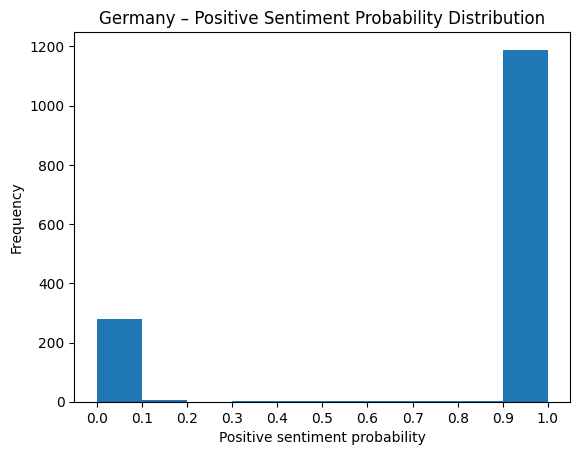

In [21]:
plt.figure()
plt.hist(de_sent["pos_prob"], bins=bins)
plt.title("Germany – Positive Sentiment Probability Distribution")
plt.xlabel("Positive sentiment probability")
plt.ylabel("Frequency")
plt.xticks(bins)
plt.show()


### 2. Does he speak more positively about China than about India? (Sentiment analysis, RoBERTa) 

China sentences: 2559
India sentences: 1071
China sentiment distribution: {'count': 2559, 'positive': 0.9015240328253223, 'negative': 0.0984759671746776}
India sentiment distribution: {'count': 1071, 'positive': 0.9393090569561158, 'negative': 0.06069094304388422}
Δ positive rate (China - India): -0.038


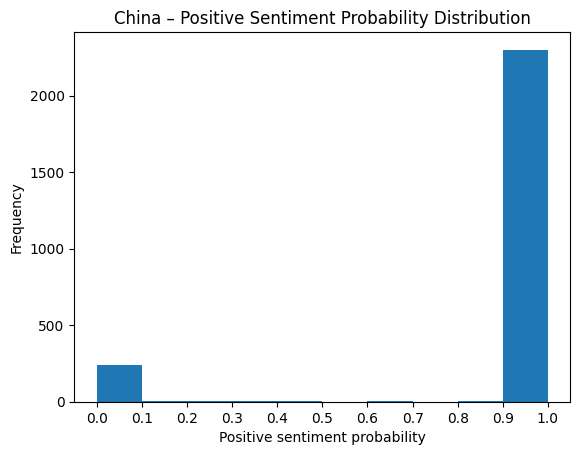

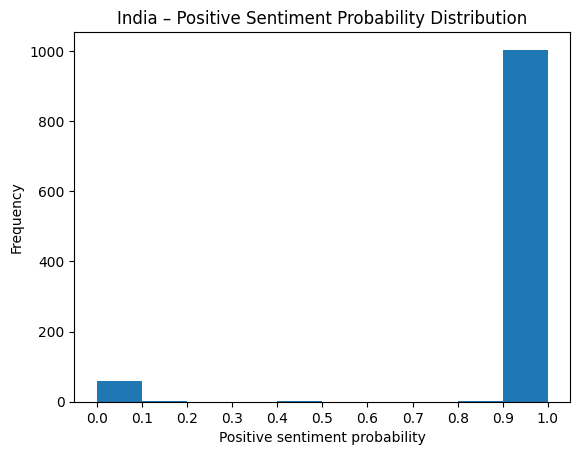

In [15]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



def batched_sentiment(texts, tokenizer, model, batch_size=16, max_length=256):
    """
    Returns:
      pos_probs: np.array of P(POSITIVE) for each text
      labels:    np.array of argmax labels (0=NEG, 1=POS)
    """
    all_pos_probs = []
    all_labels = []

    # Find POSITIVE index robustly from config
    id2label = model.config.id2label
    pos_index = [k for k, v in id2label.items() if v.upper() == "POSITIVE"][0]

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        )

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)

        pos_probs = probs[:, pos_index].cpu().numpy()
        labels = probs.argmax(dim=-1).cpu().numpy()

        all_pos_probs.extend(pos_probs.tolist())
        all_labels.extend(labels.tolist())

    return np.array(all_pos_probs), np.array(all_labels)


def sentiment_proportions(df_local):
    total = len(df_local)
    pos = int((df_local["label"] == 1).sum())
    neg = int((df_local["label"] == 0).sum())
    return {
        "count": total,
        "positive": pos / total if total else 0.0,
        "negative": neg / total if total else 0.0,
    }


def plot_posprob_hist(pos_probs, title):
    bins = np.arange(0.0, 1.0 + 0.1, 0.1)
    plt.figure()
    plt.hist(pos_probs, bins=bins)
    plt.title(title)
    plt.xlabel("Positive sentiment probability")
    plt.ylabel("Frequency")
    plt.xticks(bins)
    plt.show()




df_sent = df.explode("sentences").rename(columns={"sentences": "sentence"})
df_sent = df_sent[df_sent["sentence"].notna()]
df_sent["sentence"] = df_sent["sentence"].astype(str)
df_sent = df_sent[df_sent["sentence"].str.strip() != ""].reset_index(drop=True)



pattern_china = r"\bChina\b"
pattern_india = r"\bIndia\b"

china_sent = df_sent[df_sent["sentence"].str.contains(pattern_china, case=False, na=False)].copy()
india_sent = df_sent[df_sent["sentence"].str.contains(pattern_india, case=False, na=False)].copy()

print("China sentences:", len(china_sent))
print("India sentences:", len(india_sent))


china_texts = china_sent["sentence"].tolist()
india_texts = india_sent["sentence"].tolist()

china_pos_probs, china_labels = batched_sentiment(china_texts, tokenizer, model, batch_size=16)
india_pos_probs, india_labels = batched_sentiment(india_texts, tokenizer, model, batch_size=16)

china_sent["pos_prob"] = china_pos_probs
china_sent["label"] = china_labels

india_sent["pos_prob"] = india_pos_probs
india_sent["label"] = india_labels

china_props = sentiment_proportions(china_sent)
india_props = sentiment_proportions(india_sent)

print("China sentiment distribution:", china_props)
print("India sentiment distribution:", india_props)


if china_props["count"] > 0 and india_props["count"] > 0:
    diff = china_props["positive"] - india_props["positive"]
    print(f"Δ positive rate (China - India): {diff:+.3f}")

plot_posprob_hist(china_sent["pos_prob"].values, "China – Positive Sentiment Probability Distribution")
plot_posprob_hist(india_sent["pos_prob"].values, "India – Positive Sentiment Probability Distribution")


### 3. How does the tone toward the USA compare with that toward the European Union? (Sentiment analysis + topic modeling, RoBERTa / BERTopic)


/var/folders/z8/2kz6_sf17bxf11_h78d2_q300000gn/T/ipykernel_67087/3027798929.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  usa_sent = df_sent[df_sent["sentence"].str.contains(usa_pattern, case=False, na=False, regex=True)].copy()
/var/folders/z8/2kz6_sf17bxf11_h78d2_q300000gn/T/ipykernel_67087/3027798929.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  eu_sent  = df_sent[df_sent["sentence"].str.contains(eu_pattern,  case=False, na=False, regex=True)].copy()


USA sentences: 16627
EU sentences: 2002
USA sentiment: {'count': 16627, 'positive_rate': 0.734889035905455, 'negative_rate': 0.26511096409454504, 'mean_pos_prob': 0.7341265120251479}
EU sentiment: {'count': 2002, 'positive_rate': 0.7652347652347652, 'negative_rate': 0.23476523476523475, 'mean_pos_prob': 0.7638317053851144}
Δ mean P(positive) (USA - EU): -0.030


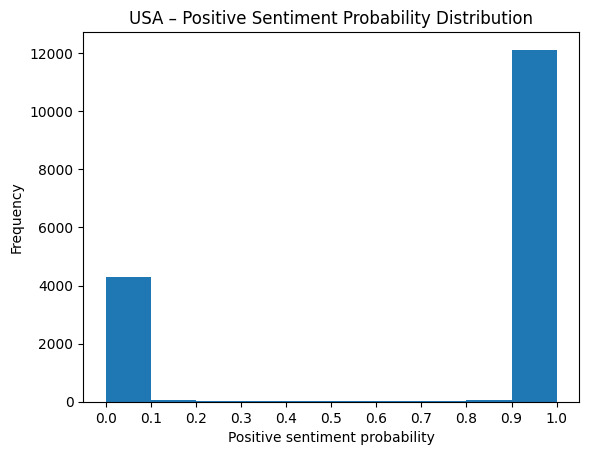

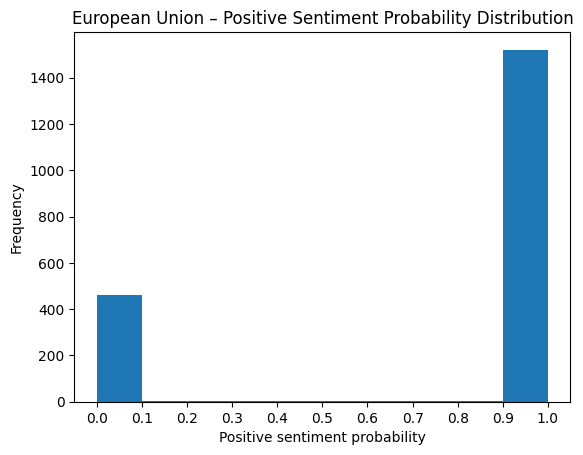

In [16]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df_sent = df.explode("sentences").rename(columns={"sentences": "sentence"})
df_sent = df_sent[df_sent["sentence"].notna()].copy()
df_sent["sentence"] = df_sent["sentence"].astype(str).str.strip()
df_sent = df_sent[df_sent["sentence"] != ""].reset_index(drop=True)


usa_pattern = r"\b(USA|U\.S\.A\.|U\.S\.|US|United States)\b"
eu_pattern  = r"\b(EU|European Union)\b"

usa_sent = df_sent[df_sent["sentence"].str.contains(usa_pattern, case=False, na=False, regex=True)].copy()
eu_sent  = df_sent[df_sent["sentence"].str.contains(eu_pattern,  case=False, na=False, regex=True)].copy()

print("USA sentences:", len(usa_sent))
print("EU sentences:", len(eu_sent))


def batched_sentiment(texts, tokenizer, model, batch_size=16, max_length=256):
    all_pos_probs, all_labels = [], []

    id2label = model.config.id2label
    pos_index = [k for k, v in id2label.items() if v.upper() == "POSITIVE"][0]

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        )

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)

        all_pos_probs.extend(probs[:, pos_index].cpu().numpy().tolist())
        all_labels.extend(probs.argmax(dim=-1).cpu().numpy().tolist())

    return np.array(all_pos_probs), np.array(all_labels)

def sentiment_summary(df_local):
    total = len(df_local)
    pos = int((df_local["label"] == 1).sum())
    neg = int((df_local["label"] == 0).sum())
    return {
        "count": total,
        "positive_rate": pos / total if total else 0.0,
        "negative_rate": neg / total if total else 0.0,
        "mean_pos_prob": float(df_local["pos_prob"].mean()) if total else 0.0
    }


usa_pos_prob, usa_label = batched_sentiment(usa_sent["sentence"].tolist(), tokenizer, model, batch_size=16)
eu_pos_prob,  eu_label  = batched_sentiment(eu_sent["sentence"].tolist(),  tokenizer, model, batch_size=16)

usa_sent["pos_prob"] = usa_pos_prob
usa_sent["label"] = usa_label

eu_sent["pos_prob"] = eu_pos_prob
eu_sent["label"] = eu_label


usa_stats = sentiment_summary(usa_sent)
eu_stats  = sentiment_summary(eu_sent)

print("USA sentiment:", usa_stats)
print("EU sentiment:", eu_stats)
print(f"Δ mean P(positive) (USA - EU): {usa_stats['mean_pos_prob'] - eu_stats['mean_pos_prob']:+.3f}")


bins = np.arange(0.0, 1.0 + 0.1, 0.1)

plt.figure()
plt.hist(usa_sent["pos_prob"], bins=bins)
plt.title("USA – Positive Sentiment Probability Distribution")
plt.xlabel("Positive sentiment probability")
plt.ylabel("Frequency")
plt.xticks(bins)
plt.show()

plt.figure()
plt.hist(eu_sent["pos_prob"], bins=bins)
plt.title("European Union – Positive Sentiment Probability Distribution")
plt.xlabel("Positive sentiment probability")
plt.ylabel("Frequency")
plt.xticks(bins)
plt.show()


We aim to determine in which thematic contexts Putin’s discourse toward the USA and the EU is framed positively or negatively. 

By applying BERTopic to identify narrative themes and combining this with RoBERTa-based sentiment analysis, we can measure tone conditional on topic. 

For example, discourse related to economic cooperation or joint counter-terrorism efforts (e.g., in Syria) is expected to exhibit more positive framing, whereas discourse related to Ukraine is hypothesized to be predominantly negative

Formally :

Sentiment( USA | Counter-terrorisme ) > Sentiment ( USA |  War in Ukraine )

In [6]:
from sentence_transformers import SentenceTransformer

EMBEDDER_DIR = "./all-mpnet-base-v2"

print("[TEST] Loading MPNet from local path:", EMBEDDER_DIR)
embedder = SentenceTransformer(EMBEDDER_DIR)

print("[TEST] Model loaded:", embedder)
print("[TEST] Device:", embedder.device)


[TEST] Loading MPNet from local path: ./all-mpnet-base-v2


SafetensorError: Error while deserializing header: header too large

In [ ]:
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm



SENTIMENT_MODEL_DIR = "./sentiment_roberta_large"

from transformers import AutoTokenizer, AutoModelForSequenceClassification

print(f"[LOAD] RoBERTa Tokenizer from: {SENTIMENT_MODEL_DIR}")
tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL_DIR, use_fast=False)

print(f"[LOAD] RoBERTa Model from: {SENTIMENT_MODEL_DIR}")
model = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL_DIR)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"[INFO] Sentiment device: {device}")
print(f"[INFO] Labels: {model.config.id2label}")


def batched_sentiment(texts, tokenizer, model, batch_size=32, max_length=256, desc="Sentiment"):
    all_pos_probs = []
    all_labels = []

    id2label = model.config.id2label
    pos_index = [k for k, v in id2label.items() if str(v).upper() == "POSITIVE"][0]

    for i in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch = texts[i:i + batch_size]

        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        )

        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)

        all_pos_probs.extend(probs[:, pos_index].detach().cpu().numpy().tolist())
        all_labels.extend(probs.argmax(dim=-1).detach().cpu().numpy().tolist())

    return np.array(all_pos_probs), np.array(all_labels)


def add_sentiment_columns(df_local, text_col="sentence", name=""):
    print(f"\n=== [SENTIMENT] {name} ===")
    texts = df_local[text_col].fillna("").astype(str).tolist()
    print(f"[SENTIMENT] N={len(texts)}")

    pos_probs, labels = batched_sentiment(
        texts, tokenizer, model,
        batch_size=32,
        max_length=256,
        desc=f"Sentiment {name}"
    )

    df_local["pos_prob"] = pos_probs
    df_local["label"] = labels

    print(f"[SENTIMENT] Done. mean P(pos) = {df_local['pos_prob'].mean():.4f}")
    return df_local



from sentence_transformers import SentenceTransformer

EMBEDDER_DIR = "./all-mpnet-base-v2"
print(f"\n[LOAD] MPNet embedder from local path: {EMBEDDER_DIR}")
embedder = SentenceTransformer(EMBEDDER_DIR)
print("[LOAD] MPNet loaded successfully.")


# ============================
# 4) BERTopic imports (local package)
# ============================

try:
    from bertopic import BERTopic
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "BERTopic is not installed. Run:\n"
        "  pip install -U bertopic umap-learn hdbscan\n"
        "then restart the kernel."
    )


# ============================
# 5) Fit BERTopic with progress logs
# ============================

def fit_topics_with_progress(texts, min_topic_size=20, name=""):
    print(f"\n=== [BERTOPIC START] {name} ===")
    print(f"[BERTOPIC] N={len(texts)}")
    print("[BERTOPIC] Embedding -> UMAP -> HDBSCAN -> c-TF-IDF ...")

    topic_model = BERTopic(
        embedding_model=embedder,
        min_topic_size=min_topic_size,
        calculate_probabilities=False,
        verbose=True
    )

    topics, _ = topic_model.fit_transform(texts)

    n_topics = len(set(topics)) - (1 if -1 in topics else 0)
    n_outliers = int((np.array(topics) == -1).sum())

    print(f"=== [BERTOPIC DONE] {name} ===")
    print(f"[BERTOPIC] topics={n_topics} | outliers(-1)={n_outliers}")

    return topic_model, topics


# ============================
# 6) Topic summary (freq + keywords + tone)
# ============================

def topic_summary(df_local, topic_model, top_n_topics=10, name=""):
    print(f"\n=== [SUMMARY] {name} ===")

    freq = df_local["topic"].value_counts().reset_index()
    freq.columns = ["topic", "count"]
    freq = freq[freq["topic"] != -1].copy()

    if len(freq) == 0:
        print("[SUMMARY] No valid topics.")
        return freq

    freq["share"] = freq["count"] / freq["count"].sum()
    freq = freq.sort_values("count", ascending=False).head(top_n_topics)

    print("[SUMMARY] Extracting keywords...")

    def keywords_for_topic(t):
        words = topic_model.get_topic(int(t))
        if not words:
            return ""
        return ", ".join([w for (w, _) in words[:10]])

    freq["keywords"] = freq["topic"].apply(keywords_for_topic)

    print("[SUMMARY] Computing tone per topic...")

    tone = (
        df_local[df_local["topic"] != -1]
        .groupby("topic")
        .agg(
            mean_pos_prob=("pos_prob", "mean"),
            positive_rate=("label", lambda x: float((x == 1).mean())),
            n=("topic", "size")
        )
        .reset


[LOAD] Tokenizer from: ./sentiment_roberta_large
[LOAD] Model from: ./sentiment_roberta_large
[INFO] Using device: cpu
[INFO] Labels: {0: 'NEGATIVE', 1: 'POSITIVE'}

[LOAD] SentenceTransformer: all-mpnet-base-v2


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

### Change over time

1. How does the image of Ukraine (Poland, Germany, USA) change in his speeches from 
2000 to 2024? (Sentiment analysis + temporal aggregation, RoBERTa)


In [30]:
import re

df["sentences"] = df["transcript_filtered"].fillna("").astype(str).apply(
    lambda x: re.split(r"(?<=[.!?])\s+", x.strip()) if x.strip() else []
)

df_sent = df.explode("sentences").rename(columns={"sentences": "sentence"}).copy()
df_sent["sentence"] = df_sent["sentence"].fillna("").astype(str).str.strip()
df_sent = df_sent[df_sent["sentence"] != ""].copy()

df_sent["year"] = df_sent["date"].dt.year
df_sent = df_sent[(df_sent["year"] >= 1999) & (df_sent["year"] <= 2023)].reset_index(drop=True)

print("df_sent rows:", len(df_sent))
print("year min/max:", df_sent["year"].min(), df_sent["year"].max())
print("sample sentences:", df_sent["sentence"].head(3).tolist())


df_sent rows: 377879
year min/max: 1999 2023
sample sentences: ['Dear friends, On New Year’s Eve, my family and I planned to gather round the TV, just as you probably did, to listen to the address by President Boris Yeltsin.', 'But things took a different turn.', 'On December 31, 1999, Russia’s first president decided to resign.']


In [31]:
ukraine_pattern = r"\b(?:Ukraine|Ukrainian)\b"
usa_pattern = r"\b(?:USA|U\.S\.A\.|U\.S\.|US|United States|America|American|Washington)\b"

ua_sent = df_sent[df_sent["sentence"].str.contains(ukraine_pattern, case=False, na=False, regex=True)].copy()
us_sent = df_sent[df_sent["sentence"].str.contains(usa_pattern, case=False, na=False, regex=True)].copy()

print("Ukraine sentences:", len(ua_sent))
print("USA sentences:", len(us_sent))




Ukraine sentences: 4234
USA sentences: 17646


In [33]:
import torch
from tqdm import tqdm

def batched_sentiment(texts, tokenizer, model, batch_size=32, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model.to(device)
    model.eval()

    all_pos_probs = []
    all_labels = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Running sentiment"):
            batch_texts = texts[i:i+batch_size]

            enc = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                return_tensors="pt",
                max_length=512
            )

            enc = {k: v.to(device) for k, v in enc.items()}

            outputs = model(**enc)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=-1)

            pos_probs = probs[:, 1].detach().cpu().tolist()
            labels = torch.argmax(probs, dim=1).detach().cpu().tolist()

            all_pos_probs.extend(pos_probs)
            all_labels.extend(labels)

    return all_pos_probs, all_labels


In [34]:
ua_pos_probs, ua_labels = batched_sentiment(
    ua_sent["sentence"].tolist(),
    tokenizer,
    model,
    batch_size=32
)

us_pos_probs, us_labels = batched_sentiment(
    us_sent["sentence"].tolist(),
    tokenizer,
    model,
    batch_size=32
)

ua_sent["pos_prob"] = ua_pos_probs
ua_sent["label"] = ua_labels

us_sent["pos_prob"] = us_pos_probs
us_sent["label"] = us_labels



Running sentiment: 100%|██████████| 552/552 [13:14<00:00,  1.44s/it]


In [39]:
ua_yearly = (
    ua_sent
    .groupby("year")
    .agg(
        mean_pos_prob=("pos_prob", "mean"),
        n_sentences=("pos_prob", "size")
    )
    .reset_index()
)

us_yearly = (
    us_sent
    .groupby("year")
    .agg(
        mean_pos_prob=("pos_prob", "mean"),
        n_sentences=("pos_prob", "size")
    )
    .reset_index()
)

print("Ukraine yearly sentiment:")
print(ua_yearly)

print("\nUSA yearly sentiment:")
print(us_yearly)


Ukraine yearly sentiment:
    year  mean_pos_prob  n_sentences
0   2000       0.857573           36
1   2001       0.869868           87
2   2002       0.903651           54
3   2003       0.841690          133
4   2004       0.817052          242
5   2005       0.758103          163
6   2006       0.691014          159
7   2007       0.562985           73
8   2008       0.658211           71
9   2009       0.998717            1
10  2012       0.717164           75
11  2013       0.688733          283
12  2014       0.519779          901
13  2015       0.555297          365
14  2016       0.501746          157
15  2017       0.509956          167
16  2018       0.451003          200
17  2019       0.549069          198
18  2020       0.648021           71
19  2021       0.461324          186
20  2022       0.422064          612

USA yearly sentiment:
    year  mean_pos_prob  n_sentences
0   1999       0.998851            2
1   2000       0.755941          553
2   2001       0.748869   

In [40]:
MIN_N = 10

ua_yearly_filtered = ua_yearly[ua_yearly["n_sentences"] >= MIN_N].copy()
us_yearly_filtered = us_yearly[us_yearly["n_sentences"] >= MIN_N].copy()


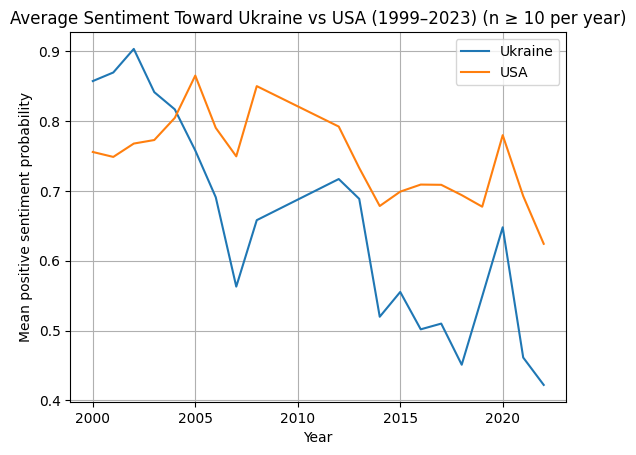

In [41]:
plt.figure()
plt.plot(ua_yearly_filtered["year"], ua_yearly_filtered["mean_pos_prob"], label="Ukraine")
plt.plot(us_yearly_filtered["year"], us_yearly_filtered["mean_pos_prob"], label="USA")

plt.title("Average Sentiment Toward Ukraine vs USA (1999–2023) (n ≥ 10 per year)")
plt.xlabel("Year")
plt.ylabel("Mean positive sentiment probability")
plt.legend()
plt.grid(True)
plt.show()


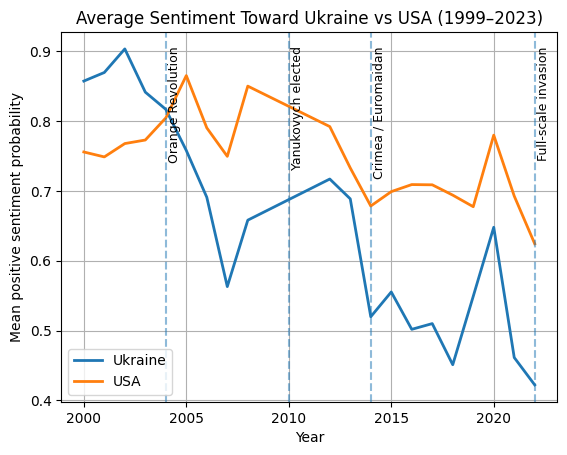

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    ua_yearly_filtered["year"],
    ua_yearly_filtered["mean_pos_prob"],
    label="Ukraine",
    linewidth=2
)

plt.plot(
    us_yearly_filtered["year"],
    us_yearly_filtered["mean_pos_prob"],
    label="USA",
    linewidth=2
)

# --- Key events (Ukraine) ---
events = {
    2004: "Orange Revolution",
    2010: "Yanukovych elected",
    2014: "Crimea / Euromaidan",
    2022: "Full-scale invasion"
}

for year, label in events.items():
    plt.axvline(year, linestyle="--", alpha=0.5)
    plt.text(
        year + 0.1,
        plt.ylim()[1] - 0.02,
        label,
        rotation=90,
        verticalalignment="top",
        fontsize=9
    )

plt.title("Average Sentiment Toward Ukraine vs USA (1999–2022)")
plt.xlabel("Year")
plt.ylabel("Mean positive sentiment probability")
plt.legend()
plt.grid(True)
plt.show()
